In [1]:
import sys
sys.path.append("..")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.data import load_frozen_session
from src.tightness import bar_range, coverage_stats, drop_zero_volume

LIQUID, ILLIQUID = "AAPL", "SIF"

In [2]:
data = {t: load_frozen_session(t) for t in (LIQUID, ILLIQUID)}

pd.DataFrame({t: coverage_stats(df) for t, df in data.items()}).T

,bars_reported,zero_volume_bars,bars_with_trades,coverage,effective_coverage
AAPL,390.0,0.0,390.0,1.000000,1.000000
SIF,77.0,1.0,76.0,0.197436,0.194872


## 1. Datos

Barras de 1 minuto del 2026-08-28 para AAPL (líquido) y SIF (ilíquido).
Selección de tickers en `scripts/explore_tickers.py`.

yfinance omite el minuto si no hubo trades. Por eso SIF reporta 77 barras
y AAPL 390: las faltantes son minutos sin mercado, no datos perdidos.
Cobertura efectiva de SIF: 19.5%.

In [3]:
clean = {t: drop_zero_volume(df) for t, df in data.items()}
ranges = {t: bar_range(df) for t, df in clean.items()}

pd.DataFrame({t: r.describe() for t, r in ranges.items()})

,AAPL,SIF
count,390.000000,76.000000
mean,0.000877,0.001937
std,0.000608,0.003612
min,0.000219,0.000000
25%,0.000500,0.000000
50%,0.000734,0.000000
75%,0.001096,0.002451
max,0.006893,0.016565


In [4]:
for t, r in ranges.items():
    print(f"{t}: {(r == 0).mean():.1%} de barras planas ({(r == 0).sum()} de {len(r)})")

AAPL: 0.0% de barras planas (0 de 390)
SIF: 60.5% de barras planas (46 de 76)


## 2. Proxy de tightness

`(high - low) / close` por barra, normalizado por precio para que AAPL (~$230)
y SIF (~$23) sean comparables.

En media SIF dobla a AAPL (0.0019 vs 0.0009), pero su mediana es 0: el 60.5% de
sus barras tienen `high == low`, con volumen distinto de cero. Son minutos con
trades, todos al mismo precio.

La distribución de SIF no es más ancha, es bimodal: muchos ceros y saltos grandes
(máximo 0.0166 contra 0.0069 de AAPL). Medido por mediana, el proxy diría que el
ilíquido es más apretado que el líquido.

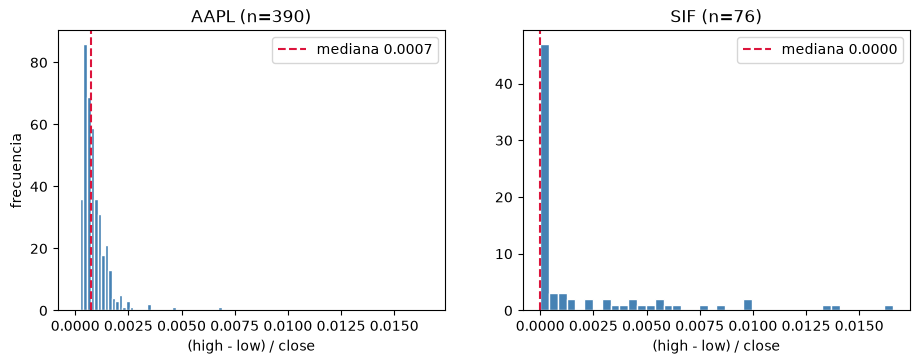

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharex=True)

for ax, (t, r) in zip(axes, ranges.items()):
    ax.hist(r, bins=40, color="steelblue", edgecolor="white")
    ax.set_title(f"{t} (n={len(r)})")
    ax.set_xlabel("(high - low) / close")
    ax.axvline(r.median(), color="crimson", ls="--", label=f"mediana {r.median():.4f}")
    ax.legend()

axes[0].set_ylabel("frecuencia")
fig.subplots_adjust(bottom=0.18)
plt.savefig("outputs/tightness_hist.png", dpi=150, bbox_inches="tight")
plt.show()

In [7]:
from src.gbm import calibrate_sigma, simulate_gbm, terminal_moments

sigma = calibrate_sigma(clean[LIQUID]["Close"])
s0 = float(clean[LIQUID]["Close"].iloc[-1])
T = 1.0

print(f"sigma anualizada: {sigma:.4f}")
print(f"S0: {s0:.2f}")

sigma anualizada: 0.1913
S0: 319.64


In [8]:
paths = simulate_gbm(s0, sigma, T)
terminal = paths[:, -1]

theory = terminal_moments(s0, sigma, T)
result = pd.DataFrame({
    "simulado": [terminal.mean(), np.median(terminal)],
    "teorico": [theory["mean"], theory["median"]],
}, index=["media", "mediana"])
result["error_rel"] = (result["simulado"] / result["teorico"] - 1).abs()
result

,simulado,teorico,error_rel
media,320.187498,319.640015,0.001713
mediana,314.098919,313.844126,0.000812


In [9]:
se_mean = terminal.std(ddof=1) / np.sqrt(len(terminal))
z = abs(terminal.mean() - theory["mean"]) / se_mean
print(f"error estandar de la media: {se_mean:.4f}")
print(f"desviaciones estandar: {z:.2f}")

error estandar de la media: 0.6202
desviaciones estandar: 0.88


## 3. Simulación GBM

10,000 trayectorias, sigma calibrada de AAPL (19.13% anualizada), mu = 0
para aislar el efecto de Itô. SIF no sirve para calibrar: 76 barras, 60% planas.

Media 320.19 vs mediana 314.10. La diferencia es `exp(-σ²T/2)`: la lognormal
tiene cola derecha larga, la media se estira y la mediana no.

El error de la media (0.17%) rebasa el 1e-3 del machote pero está a 0.88
desviaciones estándar del teórico. Es ruido de Monte Carlo; el criterio
correcto es el error estándar, no un umbral fijo.